In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os

In [ ]:
%pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


# **01. Missing Data Handling & Encoding**

Dataset Shape: (27901, 18)
Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64


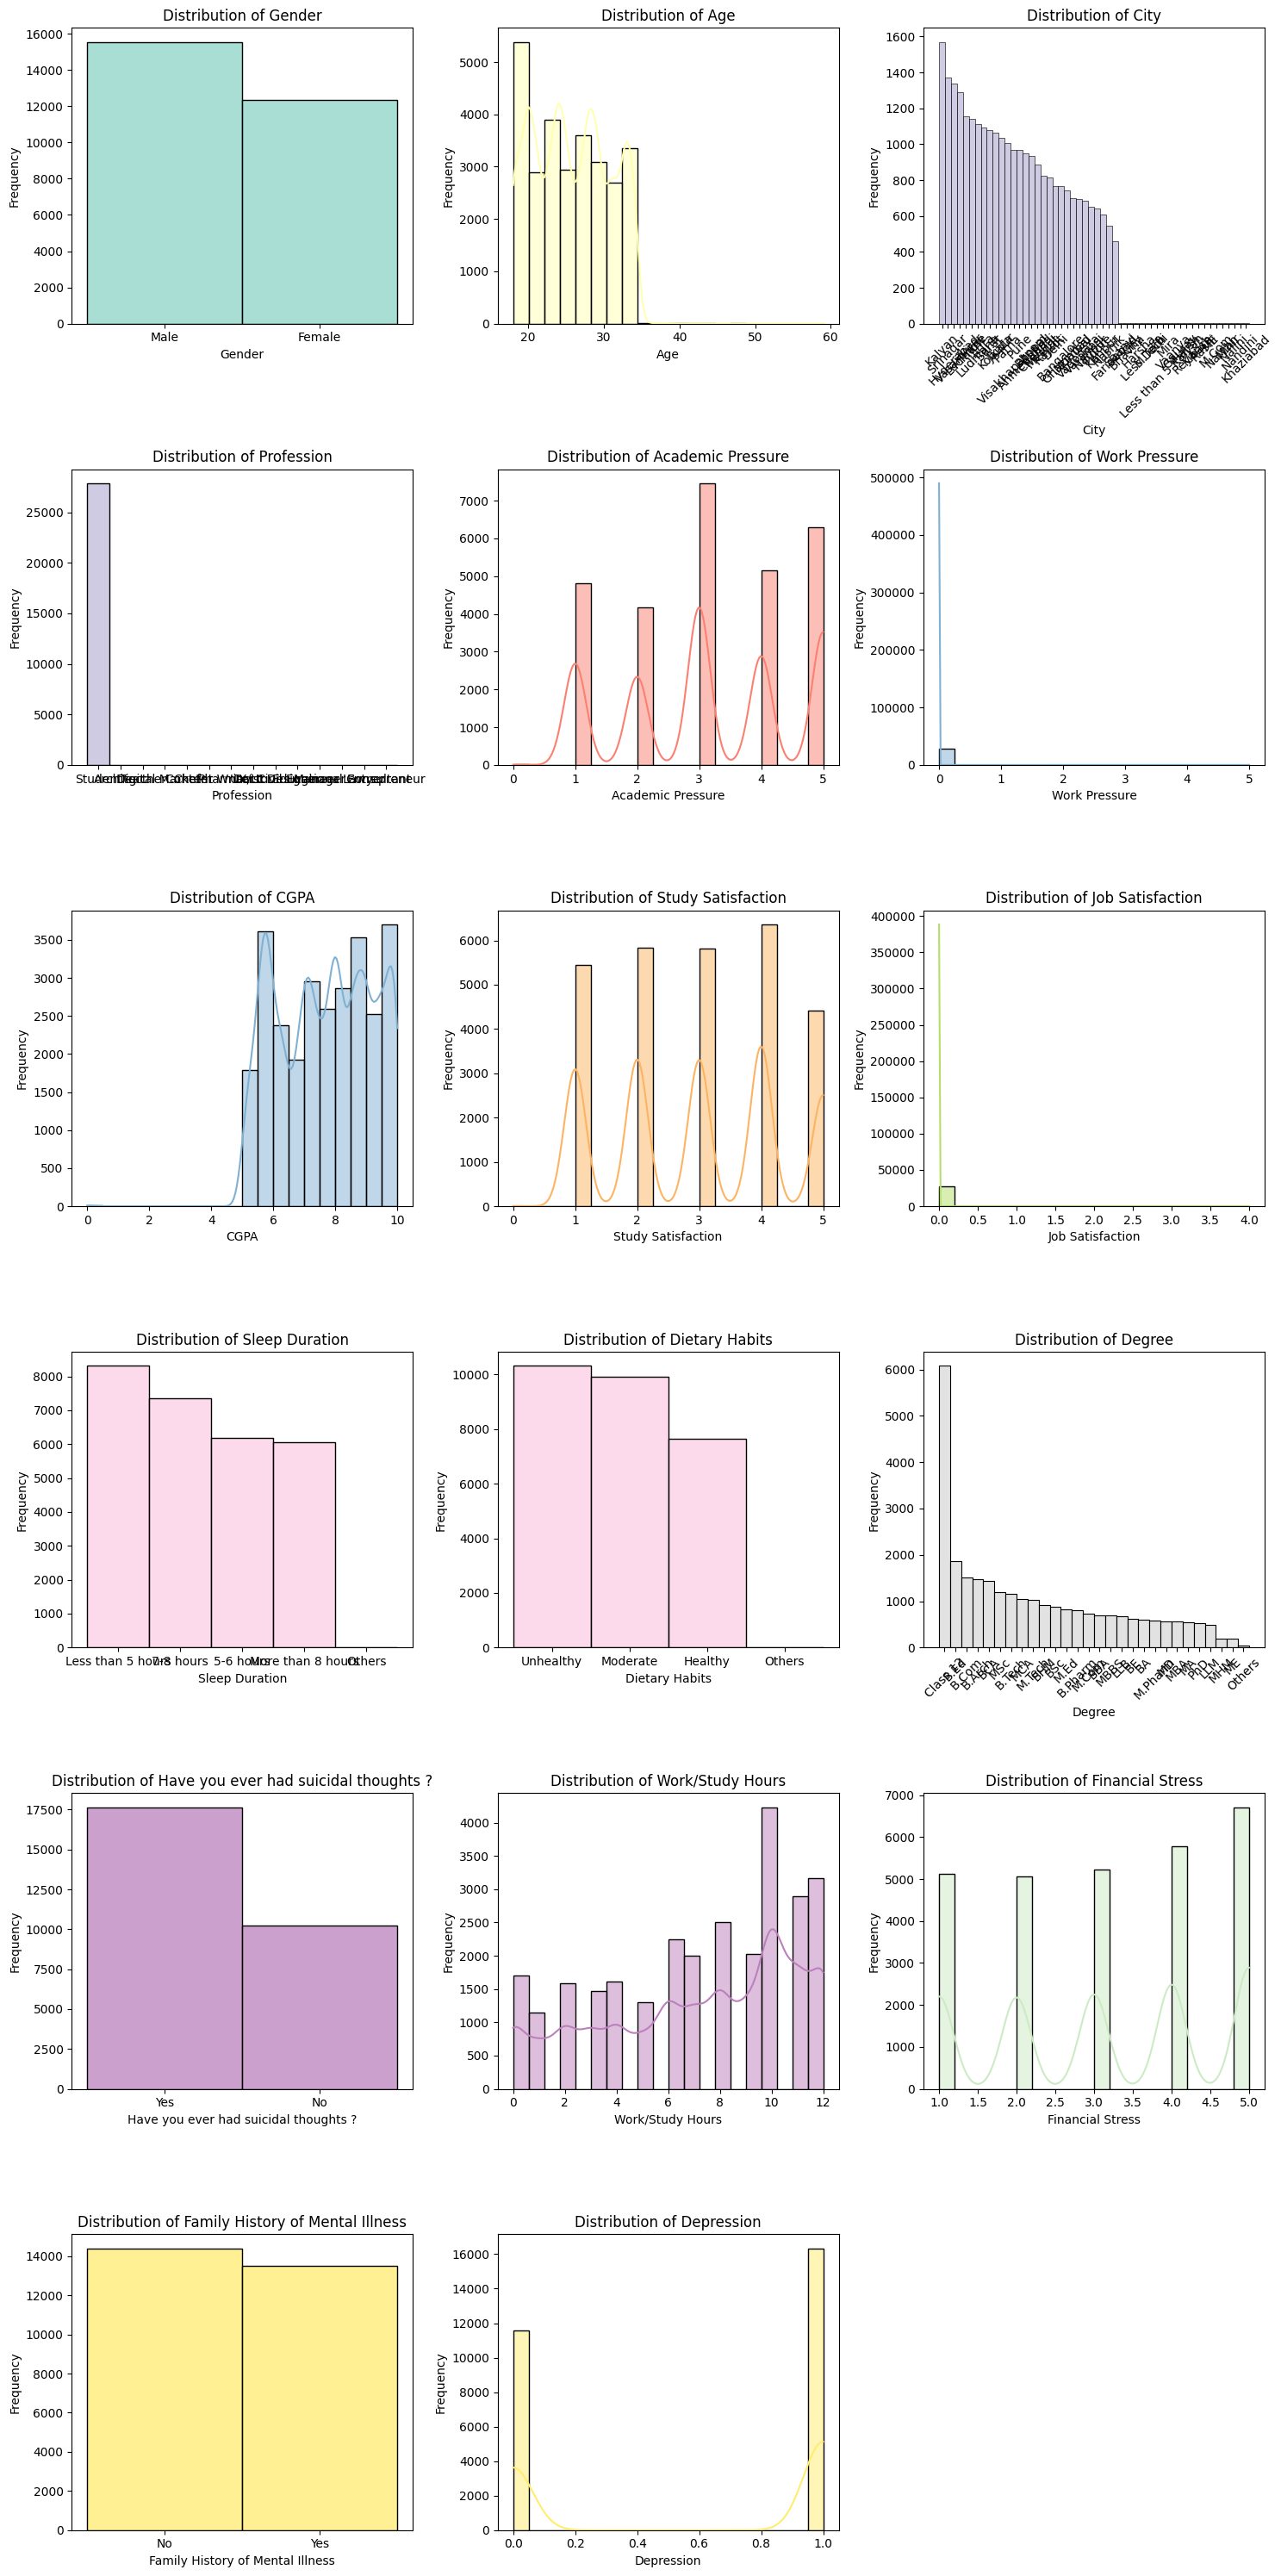

Loaded cleaned dataset. Shape: (27901, 18)
Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
id column dropped

Original (first 5 rows of categorical columns):
   gender suicidal_thoughts family_history profession     sleep_duration  \
0    Male               Yes             No    Student          5-6 hours   
1  Female                No            Yes    Student          5-6 hours   
2    Male                No            Yes    Student  Less than 5 hours   
3  Female               Yes            Yes    Student          7-8 hours   
4  Female               Yes             No    Student          5-6 hours   

  dietary_habits   degree           city  
0        Healthy  B.Pharm  Visakhapatnam  
1       Moderate      BSc  

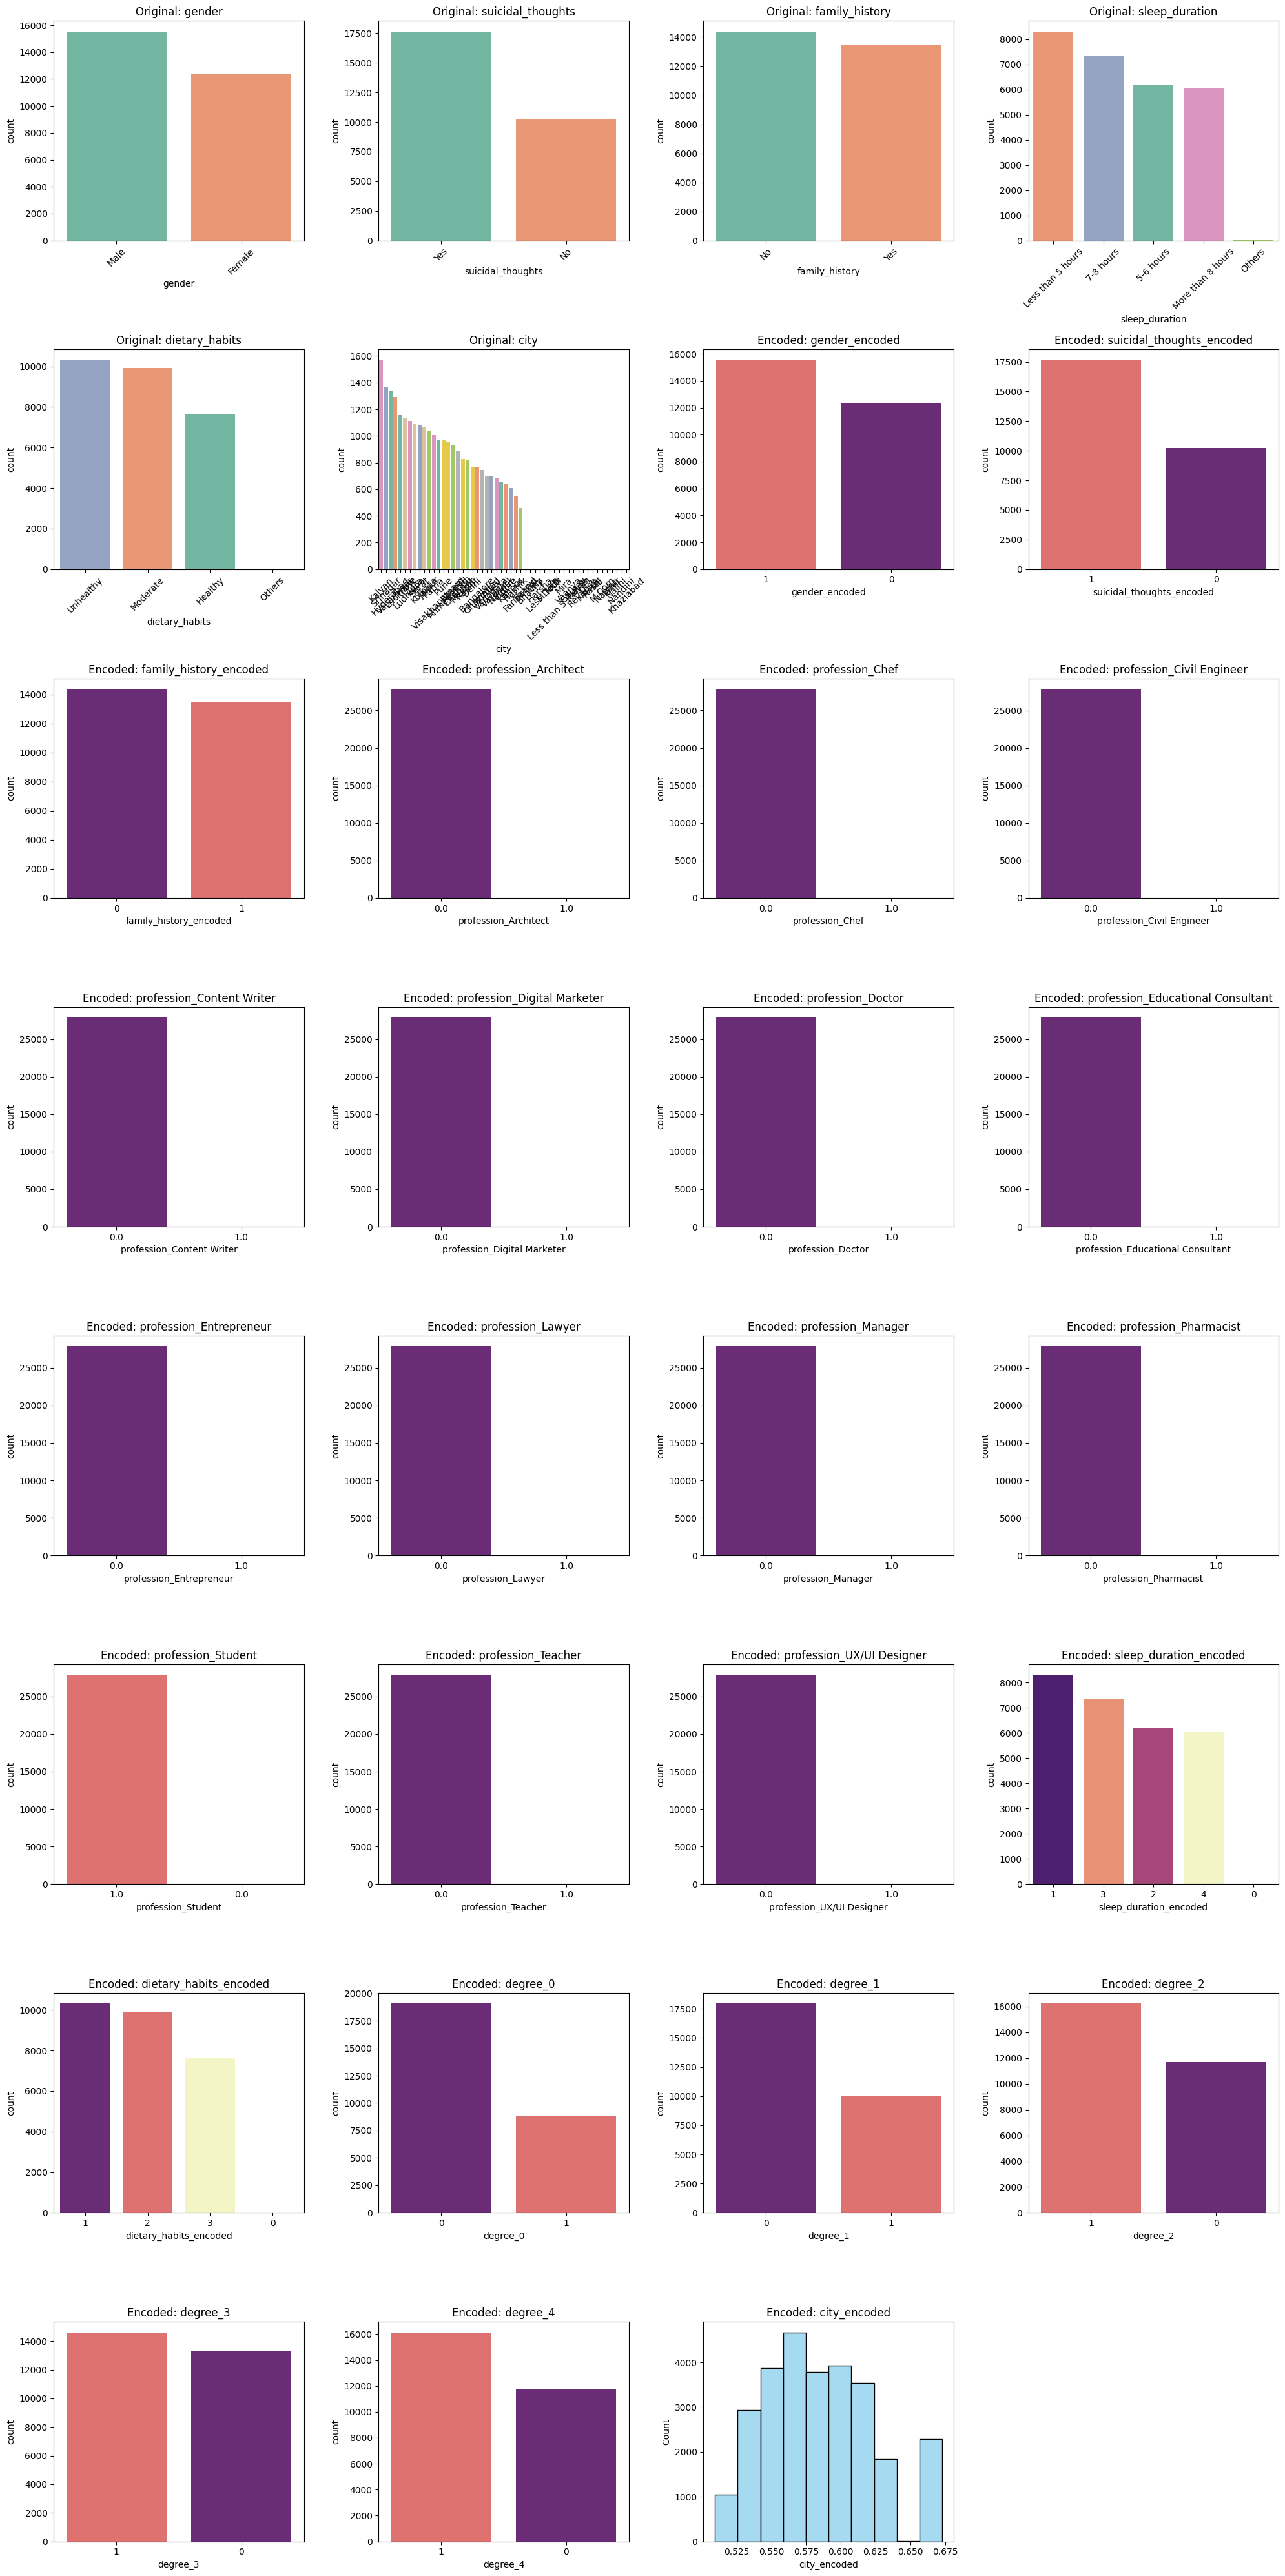


Saved: fully_encoded_student_depression_dataset.csv
Shape: (27901, 34)
Columns: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression', 'gender_encoded', 'suicidal_thoughts_encoded', 'family_history_encoded', 'profession_Architect', 'profession_Chef', 'profession_Civil Engineer', 'profession_Content Writer', 'profession_Digital Marketer', 'profession_Doctor', 'profession_Educational Consultant', 'profession_Entrepreneur', 'profession_Lawyer', 'profession_Manager', 'profession_Pharmacist', 'profession_Student', 'profession_Teacher', 'profession_UX/UI Designer', 'sleep_duration_encoded', 'dietary_habits_encoded', 'degree_0', 'degree_1', 'degree_2', 'degree_3', 'degree_4', 'city_encoded']


In [ ]:
##1. Data Cleaning (Missing & Duplicate Handling)

# Load the dataset
df = pd.read_csv('Student Depression Dataset.csv')
print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.info()
print('\nFirst 5 Rows:')
print(df.head())

# Step 1: Check Missing Values
missing_values = df.isna().sum()
print('\nMissing Values per Column:')
print(missing_values)
missing_percent = (missing_values / len(df)) * 100
print('\nMissing Values Percentage:')
print(missing_percent)

# Impute numeric with median, categorical with mode
if missing_values.sum() > 0:
    fill_values = {}
    for col in df.select_dtypes(include=['float64','int64']).columns:
        if missing_values[col] > 0:
            fill_values[col] = df[col].median()
    for col in df.select_dtypes(include=['object']).columns:
        if missing_values[col] > 0:
            fill_values[col] = df[col].mode()[0]
    df.fillna(fill_values, inplace=True)
    print('\nMissing Values After Handling:')
    print(df.isna().sum())
else:
    print('\nNo missing values found.')

# Step 2: Duplicates
duplicates_count = df.duplicated().sum()
print('\nDuplicate Rows:', duplicates_count)
if duplicates_count > 0:
    df = df.drop_duplicates()
    print('Duplicates Removed. New Shape:', df.shape)
else:
    print('No duplicates found.')

df.to_csv('cleaned_student_depression_dataset.csv', index=False)
print('\nSaved: cleaned_student_depression_dataset.csv')


## EDA Visualizations for Missing Data

all_cols = ['Gender','Age','City','Profession','Academic Pressure','Work Pressure',
            'CGPA','Study Satisfaction','Job Satisfaction','Sleep Duration',
            'Dietary Habits','Degree','Have you ever had suicidal thoughts ?',
            'Work/Study Hours','Financial Stress','Family History of Mental Illness','Depression']
n_c = len(all_cols)
n_r = (n_c + 2) // 3
plt.figure(figsize=(15, 5*n_r))
for i, col in enumerate(all_cols, 1):
    plt.subplot(n_r, 3, i)
    if df[col].dtype in ['float64','int64']:
        sns.histplot(data=df, x=col, bins=20, kde=True, color=plt.cm.Set3(i/n_c))
    else:
        cd = df[col].value_counts().reset_index()
        cd.columns = [col,'count']
        sns.histplot(data=cd, x=col, weights='count', color=plt.cm.Set3(i/n_c), discrete=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45 if col in ('City','Degree') else 0)
plt.tight_layout()
output_dir = 'results/eda_visualizations/1'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir,'all_columns_histogram.png'))
plt.show()


##2. Encoding Categorical Variables

try:
    from category_encoders import BinaryEncoder, TargetEncoder
    category_encoders_available = True
except ImportError:
    print('Warning: category_encoders not found. Binary and Target encoding will be skipped.')
    category_encoders_available = False

df = pd.read_csv('cleaned_student_depression_dataset.csv')
# ── Debug print ──────────────────────────────────────────────
print('Loaded cleaned dataset. Shape:', df.shape)
print('Columns:', df.columns.tolist())

if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print('id column dropped')

column_renames = {
    'Gender':'gender', 'Have you ever had suicidal thoughts ?':'suicidal_thoughts',
    'Family History of Mental Illness':'family_history', 'Profession':'profession',
    'Sleep Duration':'sleep_duration', 'Dietary Habits':'dietary_habits',
    'Degree':'degree', 'City':'city'
}
df.rename(columns=column_renames, inplace=True)

cat_cols = ['gender','suicidal_thoughts','family_history','profession',
            'sleep_duration','dietary_habits','degree','city']
print('\nOriginal (first 5 rows of categorical columns):')
print(df[cat_cols].head())

# 1. Label Encoding — binary columns
le = LabelEncoder()
for col in ['gender','suicidal_thoughts','family_history']:
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    print(f'{col} mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# 2. One-Hot Encoding — profession
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded = ohe.fit_transform(df[['profession']])
ohe_cols = ohe.get_feature_names_out(['profession'])
df = pd.concat([df, pd.DataFrame(ohe_encoded, columns=ohe_cols, index=df.index)], axis=1)
df.drop('profession', axis=1, inplace=True)
print('\nOne-Hot encoded profession columns:', list(ohe_cols))

# 3. Ordinal Encoding — sleep_duration & dietary_habits
# FIX: Others=0 (unclassified/unknown), NOT 4.
# Previous code had Others=4 which wrongly implies it means more sleep than 8 hours.
ordinal_mapping_sleep = {
    'Others':0, 'Less than 5 hours':1, '5-6 hours':2,
    '7-8 hours':3, 'More than 8 hours':4
}
ordinal_mapping_diet = {
    'Others':0, 'Unhealthy':1, 'Moderate':2, 'Healthy':3
}
df['sleep_duration_encoded'] = df['sleep_duration'].map(ordinal_mapping_sleep).astype('Int64')
df['dietary_habits_encoded'] = df['dietary_habits'].map(ordinal_mapping_diet).astype('Int64')
print('\nSleep ordinal mapping (Others=0=unclassified, not highest):')
print(df[['sleep_duration','sleep_duration_encoded']].value_counts().sort_index())

# 4. Binary Encoding — degree
if category_encoders_available and 'degree' in df.columns:
    be = BinaryEncoder(cols=['degree'])
    df_binary = be.fit_transform(df[['degree']])
    df = pd.concat([df, df_binary], axis=1)
    df.drop('degree', axis=1, inplace=True)
    binary_cols = [c for c in df_binary.columns if c.startswith('degree_')]
    print('\nBinary Encoded Degree Columns:', binary_cols)
else:
    print('Warning: Binary Encoding skipped.')

# 5. Target Encoding — city
if category_encoders_available and 'city' in df.columns and 'Depression' in df.columns:
    te = TargetEncoder(cols=['city'])
    df['city_encoded'] = te.fit_transform(df[['city']], df['Depression'])
    print('\nTarget Encoded city_encoded (first 5):')
    print(df[['city_encoded']].head())
else:
    print('Warning: Target Encoding skipped.')

# EDA Visualization — original vs encoded
encoded_cols = [c for c in df.columns
                if '_encoded' in c or c.startswith('profession_') or c.startswith('degree_')]
print('\nEncoded Dataset (first 5 rows):')
print(df[encoded_cols].head())

orig_present = [c for c in cat_cols if c in df.columns]
total_plots  = len(orig_present) + len(encoded_cols)
n_rows_enc   = (total_plots + 3) // 4
fig, axes    = plt.subplots(n_rows_enc, 4, figsize=(20, 5*n_rows_enc))
axes = axes.ravel()
for i, col in enumerate(orig_present):
    sns.countplot(x=col, data=df, ax=axes[i], hue=col, palette='Set2',
                  order=df[col].value_counts().index, legend=False)
    axes[i].set_title(f'Original: {col}')
    axes[i].tick_params(axis='x', rotation=45)
for i, col in enumerate(encoded_cols):
    ax = axes[i + len(orig_present)]
    if 'city_encoded' in col:
        sns.histplot(df[col], bins=10, ax=ax, color='skyblue')
    else:
        sns.countplot(x=col, data=df, ax=ax, hue=col, palette='magma',
                      order=df[col].value_counts().index, legend=False)
    ax.set_title(f'Encoded: {col}')
    ax.tick_params(axis='x', rotation=0)
for j in range(total_plots, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_dir,'categorical_encoding_visualizations.png'))
plt.show()

# Save final encoded dataset
non_cat = [c for c in df.columns if c not in cat_cols and c not in encoded_cols and c != 'id']
final_cols = non_cat + encoded_cols
df_encoded_only = df[final_cols]
df_encoded_only.to_csv('fully_encoded_student_depression_dataset.csv', index=False)
print('\nSaved: fully_encoded_student_depression_dataset.csv')
print('Shape:', df_encoded_only.shape)
print('Columns:', df_encoded_only.columns.tolist())


# **02. Outlier Detection & Removal**

Loaded shape: (27901, 34)
Columns: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression', 'gender_encoded', 'suicidal_thoughts_encoded', 'family_history_encoded', 'profession_Architect', 'profession_Chef', 'profession_Civil Engineer', 'profession_Content Writer', 'profession_Digital Marketer', 'profession_Doctor', 'profession_Educational Consultant', 'profession_Entrepreneur', 'profession_Lawyer', 'profession_Manager', 'profession_Pharmacist', 'profession_Student', 'profession_Teacher', 'profession_UX/UI Designer', 'sleep_duration_encoded', 'dietary_habits_encoded', 'degree_0', 'degree_1', 'degree_2', 'degree_3', 'degree_4', 'city_encoded']

=== Applying Outlier Handling ===

[IQR]
  IQR on Age: bounds=[7.50,43.50]  removed so far=12
  IQR on CGPA: bounds=[2.35,12.87]  removed so far=9
  IQR on Work/Study Hours: bounds=[-5.00,19.00]  removed so far=0

[CLIP]
  Clip on Academic Pressure: cappe

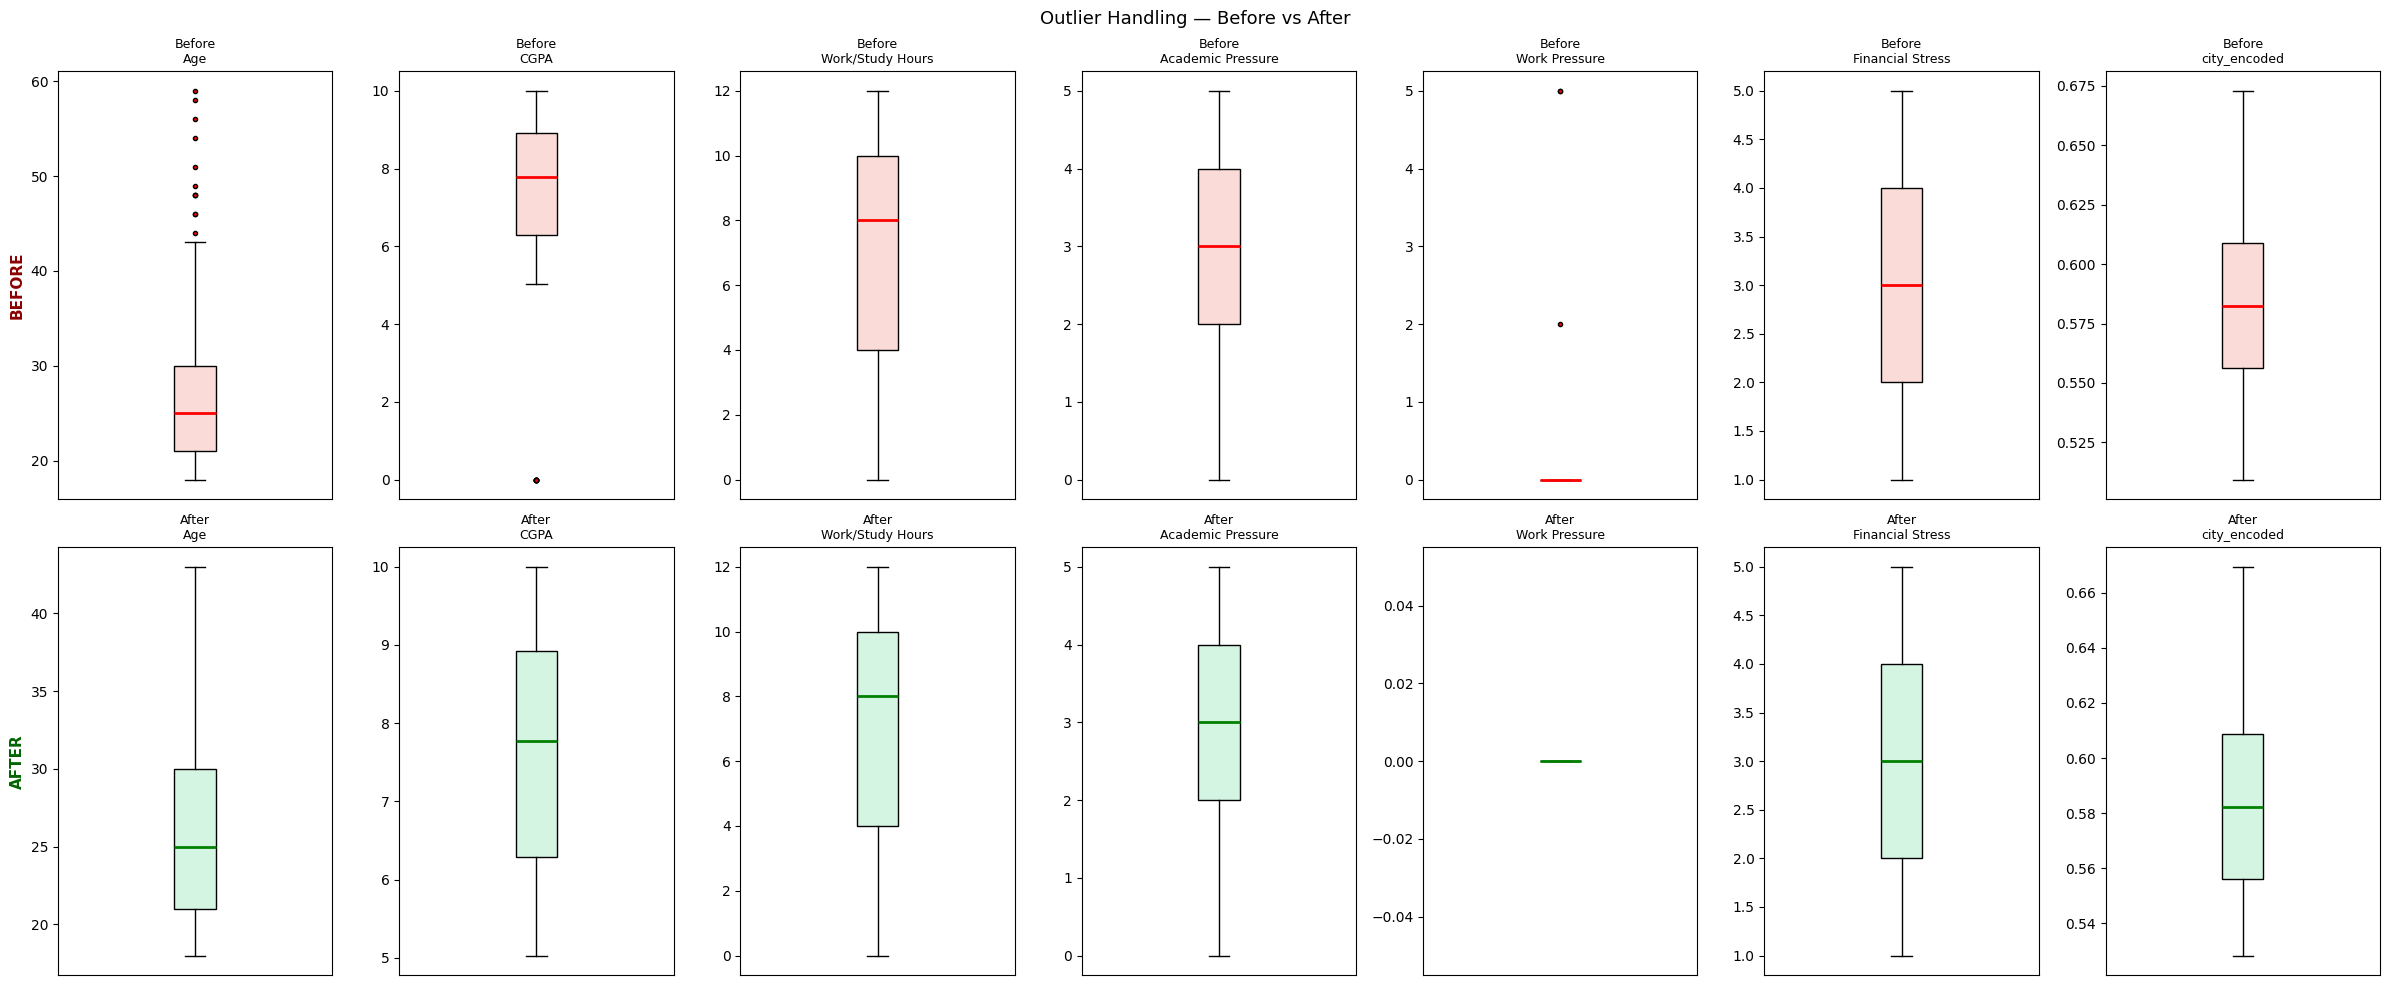


INTERPRETATION:
IQR on Age, CGPA, Work/Study Hours removes statistically impossible values.
Clipping keeps pressure/stress columns within valid scale [0,5].
Winsorization brings extreme city_encoded values within 5th-95th percentile.

Saved: outlier_handled_student_depression_dataset.csv
Shape: (27880, 34)


In [ ]:
# Load the fully encoded dataset
try:
    df = pd.read_csv('fully_encoded_student_depression_dataset.csv')
except FileNotFoundError:
    print('Error: fully_encoded_student_depression_dataset.csv not found. Run Member 1 first.')
    raise

# ── Debug print ──────────────────────────────────────────────
print('Loaded shape:', df.shape)
print('Columns:', df.columns.tolist())

df_original = df.copy()
df_cleaned  = df.copy()

# Step 1: Method-to-column mapping
# FIX: 'Work/Study Hours' moved from log to iqr.
# Reason: Member 3 StandardScales Work/Study Hours.
# Log-transforming AND StandardScaling the same column is double-transformation
# which changes the distribution twice and makes the feature uninterpretable.
# IQR removal is sufficient — it removes impossible values without distorting the scale.
method_to_columns = {
    'iqr'   : ['Age', 'CGPA', 'Work/Study Hours'],
    'clip'  : ['Academic Pressure', 'Work Pressure',
               'Study Satisfaction', 'Job Satisfaction', 'Financial Stress'],
    'winsor': ['city_encoded']
}

# Step 2: Outlier handling functions
def apply_iqr_removal(dataframe, columns):
    initial = len(dataframe)
    for col in columns:
        Q1  = dataframe[col].quantile(0.25)
        Q3  = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lb  = Q1 - 1.5 * IQR
        ub  = Q3 + 1.5 * IQR
        dataframe = dataframe[(dataframe[col] >= lb) & (dataframe[col] <= ub)].copy()
        print(f'  IQR on {col}: bounds=[{lb:.2f},{ub:.2f}]  removed so far={initial - len(dataframe)}')
        initial = len(dataframe)
    return dataframe

def apply_clipping(dataframe, columns, lb=0, ub=5):
    for col in columns:
        dataframe.loc[:, col] = dataframe[col].clip(lb, ub)
        print(f'  Clip on {col}: capped to [{lb},{ub}]')
    return dataframe

def apply_winsorization(dataframe, columns, lo=0.05, hi=0.95):
    for col in columns:
        if col in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[col]):
            lb = dataframe[col].quantile(lo)
            ub = dataframe[col].quantile(hi)
            dataframe.loc[:, col] = dataframe[col].clip(lb, ub)
            print(f'  Winsor on {col}: capped at {lo*100:.0f}%-{hi*100:.0f}% percentiles')
        else:
            print(f'  Warning: {col} not found or not numeric — skipping winsorization')
    return dataframe

# Step 3: Apply methods
print('\n=== Applying Outlier Handling ===')
for method, cols in method_to_columns.items():
    print(f'\n[{method.upper()}]')
    if method == 'iqr':
        df_cleaned = apply_iqr_removal(df_cleaned, cols)
    elif method == 'clip':
        df_cleaned = apply_clipping(df_cleaned, cols)
    elif method == 'winsor':
        df_cleaned = apply_winsorization(df_cleaned, cols)

# Step 4: Summary
print(f'\nRows before : {len(df_original):,}')
print(f'Rows after  : {len(df_cleaned):,}')
print(f'Rows removed: {len(df_original)-len(df_cleaned):,} ({(len(df_original)-len(df_cleaned))/len(df_original)*100:.1f}%)')

# Step 5: Before & After boxplots
viz_cols   = ['Age','CGPA','Work/Study Hours','Academic Pressure','Work Pressure','Financial Stress','city_encoded']
output_dir = 'results/eda_visualizations/2'
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(2, len(viz_cols), figsize=(24, 10))
for i, col in enumerate(viz_cols):
    if col in df_original.columns:
        axes[0][i].boxplot(df_original[col].dropna(), patch_artist=True,
                           boxprops=dict(facecolor='#fadbd8'),
                           medianprops=dict(color='red', linewidth=2),
                           flierprops=dict(marker='o', markerfacecolor='red', markersize=3))
        axes[0][i].set_title(f'Before\n{col}', fontsize=9)
        axes[0][i].set_xticks([])
    if col in df_cleaned.columns:
        axes[1][i].boxplot(df_cleaned[col].dropna(), patch_artist=True,
                           boxprops=dict(facecolor='#d5f5e3'),
                           medianprops=dict(color='green', linewidth=2),
                           flierprops=dict(marker='o', markerfacecolor='orange', markersize=3))
        axes[1][i].set_title(f'After\n{col}', fontsize=9)
        axes[1][i].set_xticks([])
axes[0][0].set_ylabel('BEFORE', fontsize=11, fontweight='bold', color='darkred')
axes[1][0].set_ylabel('AFTER',  fontsize=11, fontweight='bold', color='darkgreen')
plt.suptitle('Outlier Handling — Before vs After', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir,'outliers_before_after.png'), dpi=150)
plt.show()

print('\nINTERPRETATION:')
print('IQR on Age, CGPA, Work/Study Hours removes statistically impossible values.')
print('Clipping keeps pressure/stress columns within valid scale [0,5].')
print('Winsorization brings extreme city_encoded values within 5th-95th percentile.')

# Step 6: Save
df_cleaned.to_csv('outlier_handled_student_depression_dataset.csv', index=False)
print('\nSaved: outlier_handled_student_depression_dataset.csv')
print('Shape:', df_cleaned.shape)


# **03. Feature Scaling**

Loaded shape: (27880, 34)
Columns: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression', 'gender_encoded', 'suicidal_thoughts_encoded', 'family_history_encoded', 'profession_Architect', 'profession_Chef', 'profession_Civil Engineer', 'profession_Content Writer', 'profession_Digital Marketer', 'profession_Doctor', 'profession_Educational Consultant', 'profession_Entrepreneur', 'profession_Lawyer', 'profession_Manager', 'profession_Pharmacist', 'profession_Student', 'profession_Teacher', 'profession_UX/UI Designer', 'sleep_duration_encoded', 'dietary_habits_encoded', 'degree_0', 'degree_1', 'degree_2', 'degree_3', 'degree_4', 'city_encoded']
Scaling: ['Age', 'CGPA', 'Work/Study Hours', 'city_encoded', 'Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction', 'Financial Stress']

StandardScaler applied. New _standard columns created.

Before CGPA: {'count': 27880.0, 'mean'

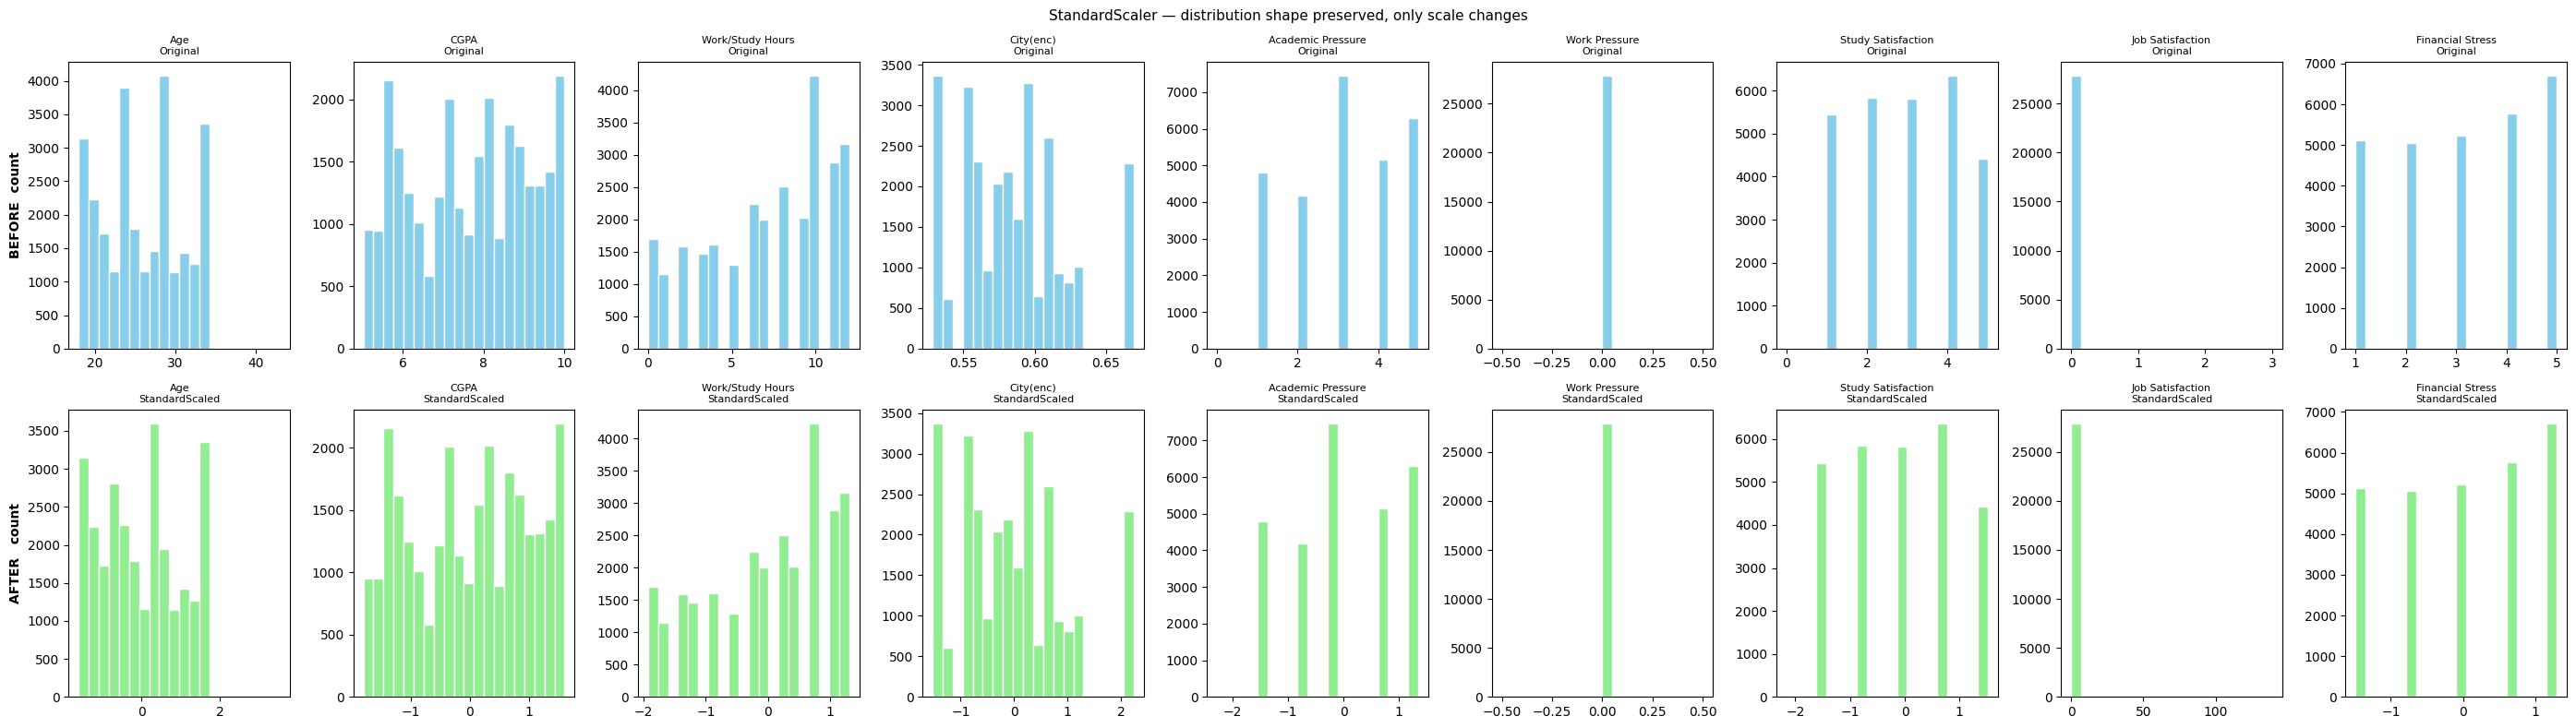


INTERPRETATION:
Shape is identical before and after — StandardScaler only changes the numeric range.
After scaling: mean=0, std=1 for all columns.
This ensures all features contribute equally in distance-based models (KNN, SVM).

Saved: scaled_student_depression_dataset.csv
Shape: (27880, 43)


In [ ]:
# Load outlier-handled dataset
try:
    df = pd.read_csv('outlier_handled_student_depression_dataset.csv')
except FileNotFoundError:
    print('Error: outlier_handled_student_depression_dataset.csv not found. Run Member 2 first.')
    raise

# ── Debug print ──────────────────────────────────────────────
print('Loaded shape:', df.shape)
print('Columns:', df.columns.tolist())

df_original = df.copy()

# Step 1: Columns to scale
# Note: Work/Study Hours was IQR-cleaned in Member 2 (NOT log-transformed).
# It is therefore safe and correct to StandardScale it here.
columns_to_scale = ['Age','CGPA','Work/Study Hours','city_encoded',
                    'Academic Pressure','Work Pressure',
                    'Study Satisfaction','Job Satisfaction','Financial Stress']

# Verify columns exist
missing_sc = [c for c in columns_to_scale if c not in df.columns]
if missing_sc:
    print(f'WARNING: These columns not found and will be skipped: {missing_sc}')
    columns_to_scale = [c for c in columns_to_scale if c in df.columns]
print('Scaling:', columns_to_scale)

# Step 2: Apply StandardScaler
standard_scaler = StandardScaler()
df_scaled = df_original.copy()
df_scaled[[f'{c}_standard' for c in columns_to_scale]] = \
    standard_scaler.fit_transform(df_original[columns_to_scale])
print('\nStandardScaler applied. New _standard columns created.')

# Step 3: Summary stats comparison
print('\nBefore CGPA:', df_original['CGPA'].describe().round(3).to_dict())
print('After  CGPA:', df_scaled['CGPA_standard'].describe().round(3).to_dict())
print('\nBefore Academic Pressure:', df_original['Academic Pressure'].describe().round(3).to_dict())
print('After  Academic Pressure:', df_scaled['Academic Pressure_standard'].describe().round(3).to_dict())

# Step 4: EDA Visualizations — before vs after histograms
output_dir = 'results/eda_visualizations/3'
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(2, len(columns_to_scale), figsize=(28, 8))
for i, col in enumerate(columns_to_scale):
    sc_col    = f'{col}_standard'
    disp_name = 'City(enc)' if col == 'city_encoded' else col
    axes[0][i].hist(df_original[col].dropna(), bins=20, color='skyblue', edgecolor='white')
    axes[0][i].set_title(f'{disp_name}\nOriginal', fontsize=8)
    axes[1][i].hist(df_scaled[sc_col].dropna(), bins=20, color='lightgreen', edgecolor='white')
    axes[1][i].set_title(f'{disp_name}\nStandardScaled', fontsize=8)
axes[0][0].set_ylabel('BEFORE  count', fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('AFTER   count', fontsize=10, fontweight='bold')
plt.suptitle('StandardScaler — distribution shape preserved, only scale changes', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(output_dir,'scaling_before_after.png'), dpi=150)
plt.show()

print('\nINTERPRETATION:')
print('Shape is identical before and after — StandardScaler only changes the numeric range.')
print('After scaling: mean=0, std=1 for all columns.')
print('This ensures all features contribute equally in distance-based models (KNN, SVM).')

# Step 5: Save
df_scaled.to_csv('scaled_student_depression_dataset.csv', index=False)
print('\nSaved: scaled_student_depression_dataset.csv')
print('Shape:', df_scaled.shape)



# **04. Feature Selection**

Loaded dataset shape: (27880, 43)
Columns: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression', 'gender_encoded', 'suicidal_thoughts_encoded', 'family_history_encoded', 'profession_Architect', 'profession_Chef', 'profession_Civil Engineer', 'profession_Content Writer', 'profession_Digital Marketer', 'profession_Doctor', 'profession_Educational Consultant', 'profession_Entrepreneur', 'profession_Lawyer', 'profession_Manager', 'profession_Pharmacist', 'profession_Student', 'profession_Teacher', 'profession_UX/UI Designer', 'sleep_duration_encoded', 'dietary_habits_encoded', 'degree_0', 'degree_1', 'degree_2', 'degree_3', 'degree_4', 'city_encoded', 'Age_standard', 'CGPA_standard', 'Work/Study Hours_standard', 'city_encoded_standard', 'Academic Pressure_standard', 'Work Pressure_standard', 'Study Satisfaction_standard', 'Job Satisfaction_standard', 'Financial Stress_standard']
 Created Total_S

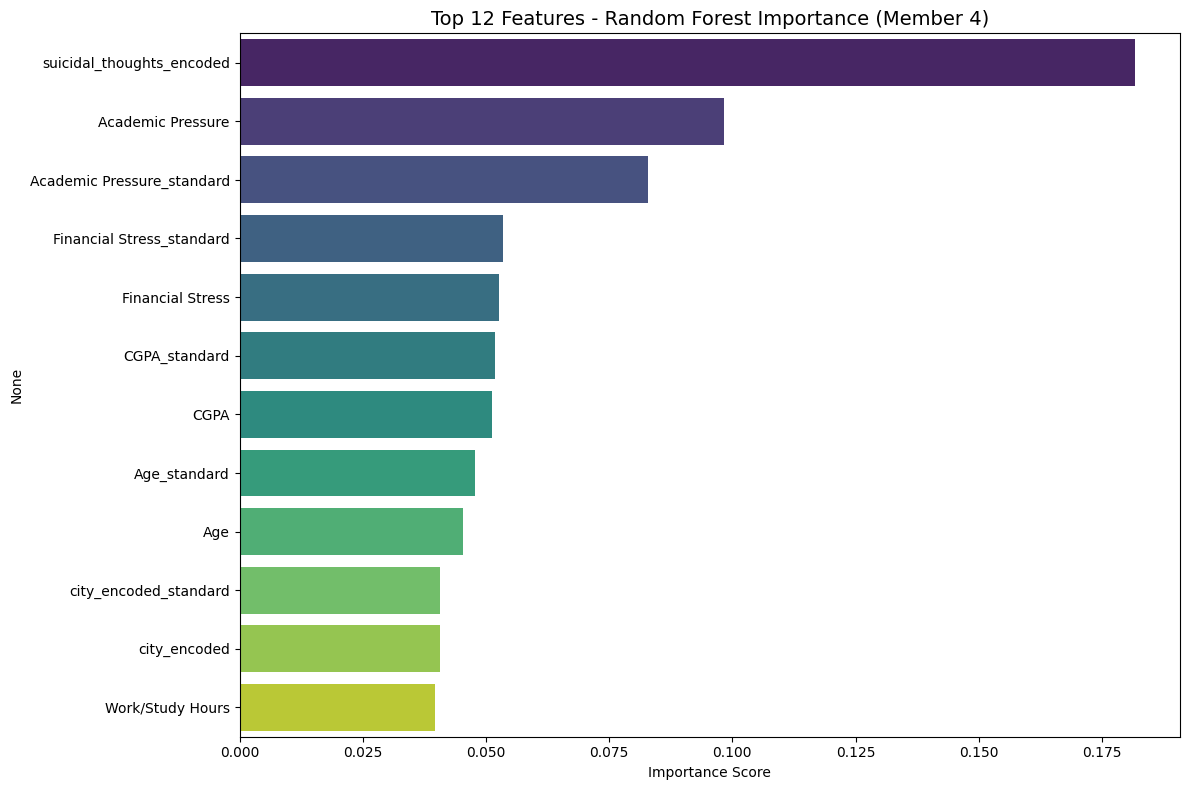

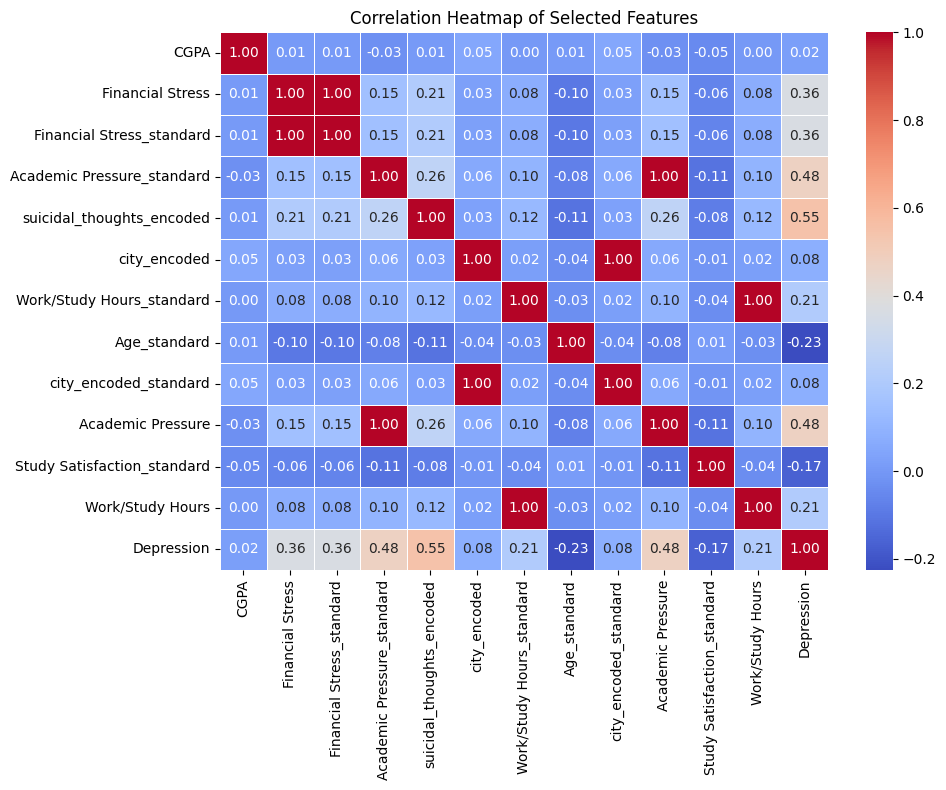


 Member 4 Completed: Feature Selection + Engineering Done
Interpretation: Academic Pressure, Financial Stress, and Total_Stress are the strongest predictors.


In [ ]:

# Load dataset from previous step
try:
    df = pd.read_csv('scaled_student_depression_dataset.csv')
except FileNotFoundError:
    print("Error: scaled_student_depression_dataset.csv not found. Run Member 3 first.")
    raise

print(f"Loaded dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Target variable
target = 'Depression'
X = df.drop(columns=[target])
y = df[target]

# Ensure X and y do not contain NaNs before feature selection
# Drop rows where X or y have NaN values. This aligns X and y,
# removing any samples that might have introduced NaNs unexpectedly.
initial_rows = X.shape[0]
combined_df = pd.concat([X, y], axis=1)
combined_df.dropna(inplace=True)
X = combined_df.drop(columns=[target])
y = combined_df[target]
if X.shape[0] < initial_rows:
    print(f"Warning: {initial_rows - X.shape[0]} rows with NaN values were removed from X and y.")

# Step 1: Feature Engineering
# Create Total_Stress (Most Important Engineered Feature)
stress_cols = ['Academic Pressure_standard', 'Work Pressure_standard', 'Financial Stress_standard']
if all(col in df.columns for col in stress_cols):
    df['Total_Stress'] = df[stress_cols].mean(axis=1)
    print(" Created Total_Stress (Feature Engineering)")
else:
    print("Warning: Some stress columns missing")

# Step 2: Feature Selection
print("\n--- Feature Selection Process ---")

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# 1. Correlation with target
corr_scores = df.corr()[target].abs().sort_values(ascending=False).drop(target)

# 2. Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# 3. Random Forest Importance
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
rf_series = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Combine top features (Ensemble Method)
top_corr = corr_scores.head(12).index.tolist()
top_mi   = mi_series.head(12).index.tolist()
top_rf   = rf_series.head(12).index.tolist()

# Final selected features (union + Total_Stress)
selected_features = list(set(top_corr + top_mi + top_rf))
if 'Total_Stress' in df.columns and 'Total_Stress' not in selected_features:
    selected_features.append('Total_Stress')

# Limit to top 12
selected_features = selected_features[:12]

print(f"\n Final Selected {len(selected_features)} Features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

# Create final dataframe
df_selected = df[selected_features + [target]]
df_selected.to_csv('selected_features_student_depression_dataset.csv', index=False)
print(f"\nSaved: selected_features_student_depression_dataset.csv | Shape: {df_selected.shape}")

# Step 3: EDA Visualizations
output_dir = 'results/eda_visualizations/4'
os.makedirs(output_dir, exist_ok=True)

# Feature Importance Bar Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=rf_series.head(12).values, y=rf_series.head(12).index, hue=rf_series.head(12).index, palette='viridis', legend=False)
plt.title('Top 12 Features - Random Forest Importance (Member 4)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'feature_importance.png'), dpi=200)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[selected_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Selected Features')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_heatmap.png'), dpi=200)
plt.show()

print("\n Member 4 Completed: Feature Selection + Engineering Done")
print("Interpretation: Academic Pressure, Financial Stress, and Total_Stress are the strongest predictors.")

# **05. Handel imbalance**

Loaded shape: (27880, 13)
Columns: ['CGPA', 'Financial Stress', 'Financial Stress_standard', 'Academic Pressure_standard', 'suicidal_thoughts_encoded', 'city_encoded', 'Work/Study Hours_standard', 'Age_standard', 'city_encoded_standard', 'Academic Pressure', 'Study Satisfaction_standard', 'Work/Study Hours', 'Depression']

Class Balance (Before Handling):
Depression
1    0.585725
0    0.414275
Name: proportion, dtype: float64
Minority class percentage: 41.43%

SMOTE Threshold: 40.0%

No SMOTE applied. Imbalance is mild.
Recommendation: Use class_weight="balanced" in models.


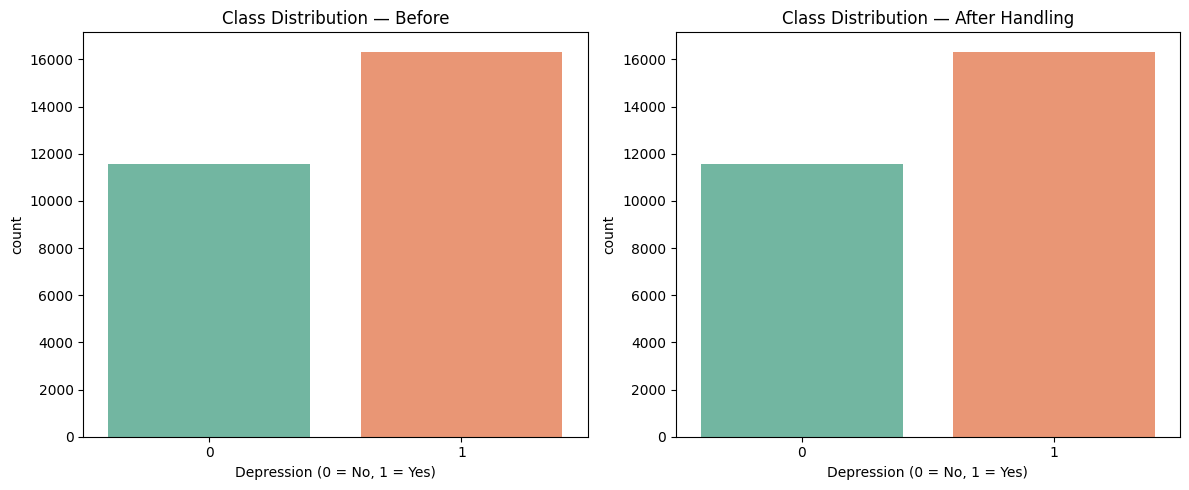

Note: Total_Stress column not found.

=== INTERPRETATION (Member 5) ===
• Minority class (No Depression) = 41.4% → Mild imbalance.
• SMOTE was NOT applied to avoid synthetic data and overfitting.
• Recommendation for modeling: Use `class_weight='balanced'` in classifiers.
• Total_Stress shows clear difference between depressed and non-depressed students.

 Final preprocessed dataset saved as final_preprocessed_student_depression_dataset.csv
Final Shape: (27880, 13)


In [ ]:
# Load dataset from Member 4
try:
    df = pd.read_csv('selected_features_student_depression_dataset.csv')
except FileNotFoundError:
    print('Error: selected_features_student_depression_dataset.csv not found. Run Member 4 first.')
    raise

print('Loaded shape:', df.shape)
print('Columns:', df.columns.tolist())

if 'Depression' not in df.columns:
    raise ValueError('Depression column not found.')

X = df.drop('Depression', axis=1)
y = df['Depression']

# Step 1: Check class distribution
class_balance = y.value_counts(normalize=True)
minority_pct = class_balance.min()
print('\nClass Balance (Before Handling):')
print(class_balance)
print(f'Minority class percentage: {minority_pct*100:.2f}%')

# Step 2: Decision on SMOTE
THRESHOLD = 0.40
print(f'\nSMOTE Threshold: {THRESHOLD*100}%')

if minority_pct < THRESHOLD:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_bal, y_bal = smote.fit_resample(X, y)
    df_balanced = pd.concat([pd.DataFrame(X_bal, columns=X.columns),
                             pd.Series(y_bal, name='Depression')], axis=1)
    print('\nSMOTE applied.')
    print('New class balance:', y_bal.value_counts(normalize=True))
else:
    df_balanced = df.copy()
    print('\nNo SMOTE applied. Imbalance is mild.')
    print('Recommendation: Use class_weight="balanced" in models.')

# Step 3: EDA Visualizations
output_dir = 'results/eda_visualizations/5'
os.makedirs(output_dir, exist_ok=True)

# 1. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y, hue=y, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Class Distribution — Before')
axes[0].set_xlabel('Depression (0 = No, 1 = Yes)')

sns.countplot(x=df_balanced['Depression'], hue=df_balanced['Depression'],
              palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Class Distribution — After Handling')
axes[1].set_xlabel('Depression (0 = No, 1 = Yes)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'class_distribution_before_after.png'), dpi=150)
plt.show()

# 2. Total_Stress Boxplot
if 'Total_Stress' in df_balanced.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_balanced, x='Depression', y='Total_Stress',
                hue='Depression', palette='Set2', legend=False)
    plt.title('Total Stress Score by Depression Status')
    plt.xlabel('Depression (0 = No, 1 = Yes)')
    plt.ylabel('Total Stress')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'total_stress_by_depression.png'), dpi=150)
    plt.show()
    print(' Total_Stress boxplot saved.')
else:
    print('Note: Total_Stress column not found.')

# Step 4: Interpretation
print('\n=== INTERPRETATION (Member 5) ===')
print(f"• Minority class (No Depression) = {minority_pct*100:.1f}% → Mild imbalance.")
print("• SMOTE was NOT applied to avoid synthetic data and overfitting.")
print("• Recommendation for modeling: Use `class_weight='balanced'` in classifiers.")
print("• Total_Stress shows clear difference between depressed and non-depressed students.")

# Final Save
df_balanced.to_csv('final_preprocessed_student_depression_dataset.csv', index=False)
print('\n Final preprocessed dataset saved as final_preprocessed_student_depression_dataset.csv')
print('Final Shape:', df_balanced.shape)